# 05d — Baseline: Gradient Boosting
**RouteRight AI — Stage 6 (Model Development)** | Owner: *(write team member name / ID here)*

This notebook runs **one** baseline model — **Gradient Boosting** — in two variants (unweighted and class-weighted) and records its results.
Everything that must be identical across the four models (data, `TimeSeriesSplit` folds, threshold, metric definitions, seed, weighting logic) lives in **`baseline_common.py`**, so the models are compared on exactly the same footing. The four results are merged in `05e_Baseline_Comparison.ipynb`.

* **Validation:** 5-fold `TimeSeriesSplit` on `train.csv` only — each fold trains on earlier rows and validates on the next block.
* **Metrics:** PR-AUC and F1 are primary (test set is more imbalanced than train: 37% vs 47% positive); accuracy, precision, recall, ROC-AUC also reported.
* **Test set:** never loaded. Kept sealed until `07_Model_Evaluation.ipynb`.
* **Baseline = library defaults.** Tuning is Stage 7.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

import baseline_common as bc

MODEL_NAME = "Gradient Boosting"
print("Project root:", bc.ROOT)

Project root: C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor


## 2. Load training data and sanity checks
Only `train.csv` is loaded. `load_train()` asserts no missing values, all-numeric features, and **chronological row order** (the assumption `TimeSeriesSplit` depends on; `opened_month` is the only time signal in this file).

In [2]:
X, y, train = bc.load_train()

Shape: (21180, 110) | missing: 0 | exact duplicate rows: 1865
Positive rate: 0.4712  (neg:pos = 1.12:1)
Rows per month (file order): {2.0: 207, 3.0: 8995, 4.0: 7934, 5.0: 4044}
Chronological order check: PASSED


## 3. Validation folds
Fold 1 trains on only ~3,500 rows (mostly Feb/March), so per-fold scores are shown, not only the mean.
**Caveat:** train contains 1,865 exact duplicate rows; a duplicate can sit on both sides of a fold boundary, making validation scores slightly optimistic (most visibly for trees). They are kept, not dropped, to preserve the documented class balance.

In [3]:
bc.fold_table(X, y)

,fold,n_train,n_val,train_pos_rate,val_pos_rate,val_months
0,1,3530,3530,0.5521,0.6110,[3]
1,2,7060,3530,0.5816,0.4530,"[3, 4]"
2,3,10590,3530,0.5387,0.4261,[4]
3,4,14120,3530,0.5106,0.3742,"[4, 5]"
4,5,17650,3530,0.4833,0.4110,[5]


## Why Gradient Boosting, and how it is set up
* **Role:** a **boosting ensemble** — shallow trees are added one at a time, each fitted to correct the errors of the previous ones. Usually the strongest family on structured tabular data.
* **Settings:** scikit-learn `GradientBoostingClassifier` defaults (100 trees, depth 3, learning rate 0.1). Shallow trees make it far less prone to memorisation than the forest or the single tree.
* **Scaling:** not needed.
* **Weighted variant:** scikit-learn's class has **no** `class_weight` or `scale_pos_weight` argument (those belong to XGBoost / LightGBM, which are not installed), so the weighted variant passes `sample_weight=compute_sample_weight("balanced", y)` to `fit()` — equivalent in effect.

In [4]:
bc.MODEL_FACTORIES[MODEL_NAME]("balanced")     # the weighted variant; unweighted is identical with class_weight=None

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

## 4. Cross-validated results

In [5]:
folds_df, oof_df = bc.run_cv(MODEL_NAME, X, y)
summary = bc.summarize(folds_df)
summary[["model", "variant", "pr_auc", "pr_auc_std", "f1", "recall", "precision", "accuracy", "roc_auc", "train_accuracy", "fit_seconds"]]

cross-validated: Gradient Boosting (unweighted)
cross-validated: Gradient Boosting (weighted)


,model,variant,pr_auc,pr_auc_std,f1,recall,precision,accuracy,roc_auc,train_accuracy,fit_seconds
0,Gradient Boosting,weighted,0.7308,0.0700,0.6156,0.5723,0.6766,0.6893,0.7558,0.7498,1.74
1,Gradient Boosting,unweighted,0.7268,0.0721,0.6351,0.6455,0.6530,0.6837,0.7527,0.7525,1.64


Per-fold PR-AUC next to the **no-skill level** (a model with no skill scores the positive rate of that validation block, so compare each fold against its own line, not against other folds).

In [6]:
bc.per_fold_view(folds_df)

,n_train,no_skill_pr_auc,pr_auc_unweighted,pr_auc_weighted
fold,,,,
1,3530,0.611,0.849,0.850
2,7060,0.453,0.713,0.715
3,10590,0.426,0.659,0.662
4,14120,0.374,0.698,0.711
5,17650,0.411,0.714,0.715


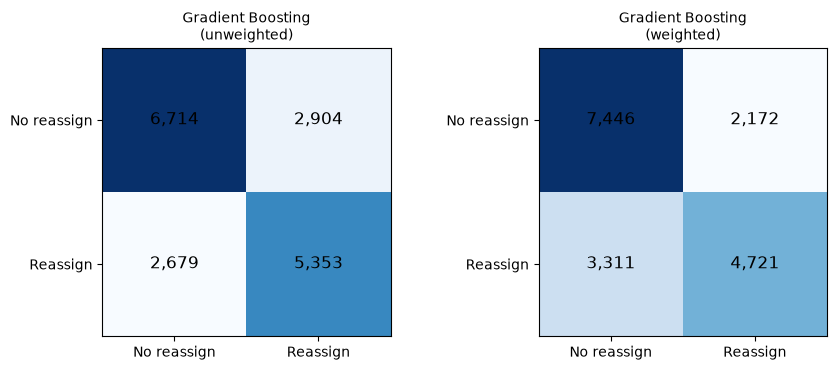

In [7]:
# Confusion matrices from pooled out-of-fold predictions (validation blocks of folds 1-5). Rows = actual, columns = predicted.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, variant in zip(axes, ["unweighted", "weighted"]):
    part = oof_df[oof_df.variant == variant]
    cm = confusion_matrix(part.y_true, part.y_pred)
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No reassign", "Reassign"]); ax.set_yticklabels(["No reassign", "Reassign"])
    ax.set_title(f"{MODEL_NAME}\n({variant})", fontsize=10)
plt.tight_layout(); plt.savefig(bc.OUT_DIR / f"baseline_{bc.slug(MODEL_NAME)}_confusion.png", dpi=130); plt.show()

## 5. Fit on the full training set and save
The model is refit on **all** of `train.csv` and saved to `models/baseline/`. Full-train accuracy is used in the comparison notebook to check against the training-accuracy ceiling. **No test data is used.**

In [8]:
full_df, fitted = bc.full_fit_and_save(MODEL_NAME, X, y)
bc.save_outputs(MODEL_NAME, folds_df, oof_df, full_df)
full_df

Saved results for Gradient Boosting to C:\Users\LOQ\OneDrive\Documents\GitHub\routeright-reassignment-predictor\docs\deliverables_eval2


,model,variant,train_accuracy_full,train_f1_full
0,Gradient Boosting,unweighted,0.7309,0.6944
1,Gradient Boosting,weighted,0.7266,0.7014


## 6. Interpretation — feature importance

Full-train accuracy: 0.7309 | CV validation accuracy: 0.6837


,importance
assignment_group_20,0.1661
u_symptom_534,0.0985
assignment_group_64,0.0881
opened_month,0.0781
assignment_group_9,0.0463
opened_by_Other,0.0402
u_symptom_532,0.0340
assignment_group_70,0.0288
opened_by_59,0.0256
category_57,0.0249


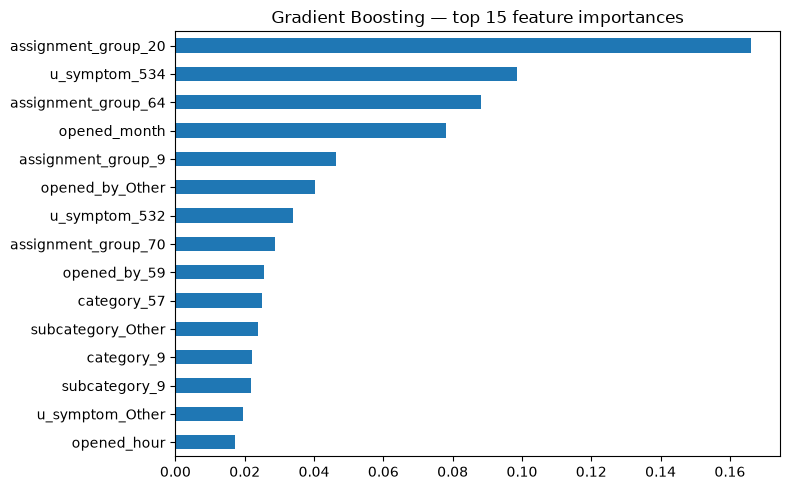

In [9]:
gb = fitted["unweighted"]
print("Full-train accuracy:", full_df.loc[full_df.variant == "unweighted", "train_accuracy_full"].iloc[0],
      "| CV validation accuracy:", summary.loc[summary.variant == "unweighted", "accuracy"].iloc[0])
imp = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False)
top = imp.head(15)
display(top.round(4).to_frame("importance"))
top.iloc[::-1].plot.barh(figsize=(8, 5), title="Gradient Boosting — top 15 feature importances")
plt.tight_layout(); plt.savefig(bc.OUT_DIR / "baseline_gradient_boosting_importance.png", dpi=130); plt.show()

## 7. Observations (numbers from the run above — re-check if you change anything)
1. **Second on PR-AUC:** ≈ 0.727 (unweighted) / 0.731 (weighted), F1 ≈ 0.62–0.64. Within ≈ 0.01 of the Random Forest, which is smaller than the fold-to-fold std (≈ 0.07).
2. **Does not overfit:** full-train accuracy ≈ 0.73 — almost the same as Logistic Regression — versus 0.99 for the forest and single tree. Depth-3 trees and the learning rate act as built-in regularisation, so it has headroom for tuning (more trees, depth, learning rate).
3. **Most different importance ranking:** it ranks `assignment_group_20`, `u_symptom_534`, `assignment_group_64` and `opened_month` at the top, and gives `opened_hour` / `opened_day_of_week` very little (≈ 0.02 / 0.005). This agrees with the Logistic Regression coefficients and suggests the time-of-day features ranked high by the forest and tree are partly overfitting artefacts.
4. **Class weighting lowers recall** (≈ 0.65 → 0.57) with PR-AUC roughly unchanged. In folds 1–3 the training set is majority-positive, so `balanced` up-weights the negative class — a consequence of the target drift, not a bug.
5. **Stage 7 plan:** tune `n_estimators`, `learning_rate`, `max_depth`, `subsample`, `min_samples_leaf` with `RandomizedSearchCV` + `TimeSeriesSplit`. Boosting is the most likely to benefit from tuning because the baseline is under-fitted, not over-fitted.